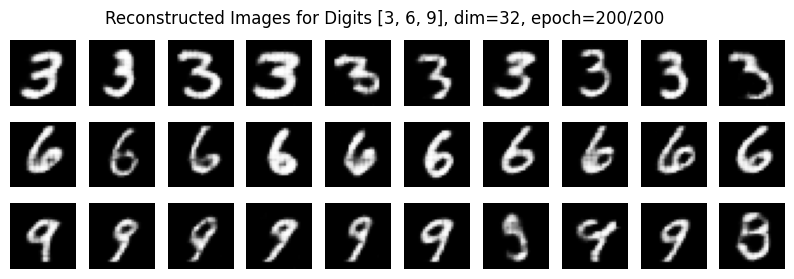

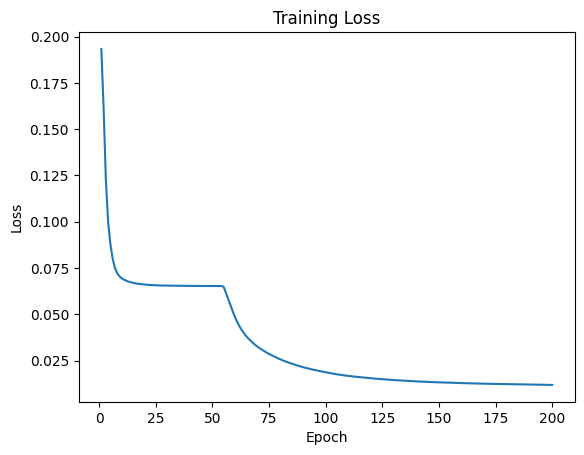

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import importlib

from modules import Autoencoder
importlib.reload(Autoencoder)  # 모듈 갱신
from IPython.display import clear_output

DIGITS = [3, 6, 9]  # 학습할 숫자들 설정
DIGITS_STR = ''.join(map(str, DIGITS))
latent_dim = 32
epochs = 200
lr = 0.0001

# 모델 초기화
autoencoder = Autoencoder.Autoencoder(latent_dim=latent_dim)
optimizer = optim.Adam(autoencoder.parameters(), lr=lr)
criterion = nn.MSELoss()

# 데이터 로더 설정 (DIGITS 필터 적용)
transform = transforms.Compose([transforms.ToTensor()])
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
filtered_data = [(img, label) for img, label in train_data if label in DIGITS]
train_loader = DataLoader(filtered_data, batch_size=64, shuffle=True)

# 오토인코더 학습
losses = []
for epoch in range(epochs):
    epoch_loss = 0  # 에포크별 손실 초기화
    batch_count = 0
    for images, _ in train_loader:
        images = images.view(-1, 1, 28, 28)
        optimizer.zero_grad()
        reconstructed = autoencoder(images)
        loss = criterion(reconstructed, images)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        batch_count += 1
    
    # 새 epoch마다 출력 클리어
    clear_output(wait=True)

    if len(DIGITS) == 1:
        # 하나의 숫자만 선택된 경우 1x10 그리드 설정
        fig, axs = plt.subplots(1, 10, figsize=(10, 1))
        digit = DIGITS[0]
        images_to_reconstruct = [img for img, label in train_data if label == digit][:10]
        images_to_reconstruct = torch.stack(images_to_reconstruct)
        reconstructed_images = autoencoder(images_to_reconstruct).detach()

        for j in range(10):
            axs[j].imshow(reconstructed_images[j].view(28, 28).numpy(), cmap='gray')
            axs[j].axis('off')
        axs[0].set_title(f"Digit {digit}", size='large')
        
    else:
        # 여러 숫자가 선택된 경우 각 숫자에 대해 1x10 그리드 설정
        fig, axs = plt.subplots(len(DIGITS), 10, figsize=(10, len(DIGITS)))
        reconstructed_images = []
        for digit in DIGITS:
            images_to_reconstruct = [img for img, label in train_data if label == digit][:10]
            images_to_reconstruct = torch.stack(images_to_reconstruct)
            reconstructed = autoencoder(images_to_reconstruct).detach()
            reconstructed_images.append((digit, reconstructed))

        for i, (digit, images) in enumerate(reconstructed_images):
            for j in range(10):
                axs[i, j].imshow(images[j].view(28, 28).numpy(), cmap='gray')
                axs[i, j].axis('off')
            axs[i, 0].set_ylabel(f"Digit {digit}", size='large')

    plt.suptitle(f"Reconstructed Images for Digits {DIGITS}, dim={latent_dim}, epoch={epoch + 1}/{epochs}")
    plt.show()

    # 그동안의 손실 전부 출력
    losses.append(epoch_loss / batch_count)
    plt.plot(range(1, len(losses) + 1), losses)
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()


In [13]:
# save & load autoencoder
save = True
load = False
if save:
    torch.save(autoencoder.state_dict(), f'savepoints/autoencoder_{DIGITS_STR}_{latent_dim}_ep{epochs}_lr{lr}.pth')
if load:
    autoencoder = Autoencoder.Autoencoder(latent_dim=latent_dim)
    autoencoder.load_state_dict(torch.load('savepoints/autoencoder.pth'))

In [ ]:
import numpy as np
import random
import torch
from torchvision import datasets, transforms

# MNIST 데이터셋 로드
transform = transforms.Compose([transforms.ToTensor()])
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# 클래스별로 2000개의 이미지를 랜덤하게 추출하여 저장할 딕셔너리 초기화
num_images_per_class = 2000
data_dict = {}

for digit in DIGITS:
    # 해당 클래스의 이미지 필터링
    images_for_class = [img for img, label in train_data if label == digit]
    print("Number of images for digit", digit, ":", len(images_for_class))
    
    # 랜덤하게 2000개의 이미지 선택
    selected_images = random.sample(images_for_class, num_images_per_class)
    
    # 원본 이미지와 latent 값 저장할 리스트
    original_images = []
    latent_vectors = []
    
    # 각 이미지를 처리하여 원본 이미지와 latent 값 추출
    for img in selected_images:
        img = img.unsqueeze(0)  # 차원 맞추기 (1, 1, 28, 28)
        original_images.append(img.numpy())  # 원본 이미지 저장
        
        # 오토인코더를 통해 latent 벡터 추출
        with torch.no_grad():
            latent_vector = autoencoder.encoder(img).numpy()
            latent_vectors.append(latent_vector)

    # numpy 배열로 변환
    original_images = np.array(original_images).squeeze()  # (2000, 28, 28)
    latent_vectors = np.array(latent_vectors).squeeze()    # (2000, latent_dim)
    print(latent_vectors.shape, latent_vectors.max(), latent_vectors.min())
    
    # data_dict에 저장
    data_dict[f'{digit}_raw'] = original_images
    data_dict[f'{digit}_latent'] = latent_vectors

# 모든 데이터를 하나의 npz 파일에 저장
import os
if not os.path.exists(f'./data/MNIST/{DIGITS_STR}_{latent_dim}_{epochs}_{lr}'):
    os.makedirs(f'./data/MNIST/{DIGITS_STR}_{latent_dim}_{epochs}_{lr}')
np.savez(f'./data/MNIST/{DIGITS_STR}_{latent_dim}_{epochs}_{lr}/mnist_{DIGITS_STR}_{latent_dim}_{num_images_per_class}.npz', **data_dict)

print("Data saved successfully.")
